# Evaluate NER predictions against gold HIPE labels

**Inputs (2 CSVs):**
- `GOLD_PATH`: the token-level extraction (`hipe2020_dev_fr_ocrqa.csv`), which carries gold `NE-COARSE-LIT` BIO labels.
- `PRED_PATH`: a sentence-level NER prediction CSV produced by `nuextract3_ner.ipynb` -- defaults to the GLiNER output (`hipe2020_dev_fr_gliner_ner.csv`); swap to `hipe2020_dev_fr_nuextract3_ner.csv` to evaluate NuExtract3 instead (that file has no `start`/`end` columns, so spans are resolved by text search instead -- handled automatically below).

**Evaluation unit**: entity spans, matched by exact character boundaries within a sentence. This project evaluates all five of HIPE's gold coarse entity types: `PER`, `LOC`, `ORG`, `TIME`, `PROD` (gold `pers`/`loc`/`org`/`time`/`prod`). Predicted entities with any other label are dropped rather than evaluated.

**Metrics**: confusion matrix, precision/recall/F1 (per-label + micro), Expected Calibration Error (ECE), and AUPRC -- the last two computed over the *predicted* entities only (confidence-scored predictions), using `is_correct` (strict span+label match) as the binary outcome.

In [1]:
!pip install pandas numpy scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
)

In [ ]:
GOLD_PATH = "hipe2020_dev_fr_ocrqa.csv"
PRED_PATH = "hipe2020_dev_fr_gliner_ner.csv"  # or "hipe2020_dev_fr_nuextract3_ner.csv"

LABELS = ["PERS", "LOC", "ORG", "TIME", "PROD"]  # HIPE's five gold coarse entity types
ALL_LABELS = LABELS + ["O"]

## 1. Build gold entity spans (character offsets) per sentence

Reconstructs sentence text directly from the gold token table using the same `MISC` `EndOfSentence`/`NoSpaceAfter` rules used to build the prediction CSVs (so `sentence_id` lines up), and closes BIO spans on `NE-COARSE-LIT` to get `(start, end, label)` gold entities.

In [4]:
LABEL_MAP = {"pers": "PERS", "loc": "LOC", "org": "ORG", "time": "TIME", "prod": "PROD"}


def bio_label(tag: str):
    """Mapped label for an in-scope B-/I- tag, or None for an unrecognized type
    (treated as non-entity)."""
    raw = tag.split("-", 1)[1]
    return LABEL_MAP.get(raw)


def build_gold(df: pd.DataFrame) -> pd.DataFrame:
    """Reconstruct sentence text and gold entity spans (char offsets + label) from NE-COARSE-LIT
    BIO tags. Returns a DataFrame of gold spans: document_id, sentence_id, start, end, label, text."""
    span_rows = []

    doc_id = None
    sent_idx = 0
    pieces: list[str] = []
    cur_len = 0
    no_space_before_next = False
    open_span = None  # {"start": int, "label": str}

    def close_span(end_pos):
        nonlocal open_span
        if open_span is not None:
            text = "".join(pieces)[open_span["start"] : end_pos]
            span_rows.append(
                {
                    "document_id": doc_id,
                    "sentence_id": sent_idx,
                    "start": open_span["start"],
                    "end": end_pos,
                    "label": open_span["label"],
                    "text": text,
                }
            )
            open_span = None

    for _, row in df.iterrows():
        if row["document_id"] != doc_id:
            close_span(cur_len)
            doc_id = row["document_id"]
            sent_idx = 0
            pieces, cur_len = [], 0
            no_space_before_next = False

        tag = str(row["NE-COARSE-LIT"])
        misc = str(row["MISC"])
        token = str(row["token"])

        if pieces and not no_space_before_next:
            pieces.append(" ")
            cur_len += 1
        start = cur_len
        pieces.append(token)
        cur_len += len(token)
        no_space_before_next = "NoSpaceAfter" in misc

        if tag.startswith("B-"):
            close_span(start)
            label = bio_label(tag)
            open_span = {"start": start, "label": label} if label is not None else None
        elif tag == "O":
            close_span(start)
        # I-X: continue the currently open span, if any

        if "EndOfSentence" in misc:
            close_span(cur_len)
            sent_idx += 1
            pieces, cur_len = [], 0
            no_space_before_next = False

    close_span(cur_len)
    return pd.DataFrame(span_rows)


gold_tokens_df = pd.read_csv(GOLD_PATH, dtype={"token": str, "MISC": str, "NE-COARSE-LIT": str})
gold_spans_df = build_gold(gold_tokens_df)
print(gold_spans_df.shape[0], "gold entity spans")
gold_spans_df.head(10)

1729 gold entity spans


,document_id,sentence_id,start,end,label,text
0,EXP-1888-08-03-a-i0030,0,58,64,LOC,Munich
1,EXP-1888-08-03-a-i0030,1,52,107,PERS,"M. Hagenbeck, le célèbre marchand d'animaux de..."
2,EXP-1888-08-03-a-i0030,1,135,142,LOC,Munich
3,EXP-1888-08-03-a-i0030,4,126,138,LOC,wigsstrasse
4,EXP-1888-08-03-a-i0030,8,42,59,ORG,Residenz-Theater
5,EXP-1888-08-03-a-i0030,22,21,34,PERS,M. Hagenbeck
6,EXP-1908-06-23-a-i0083,3,28,33,LOC,Aarau
7,EXP-1908-06-23-a-i0083,4,40,43,PERS,MM.
8,EXP-1908-06-23-a-i0083,5,44,49,LOC,Berne
9,EXP-1908-06-23-a-i0083,5,55,90,PERS,"Kraft, médecin des ôco-es dé Zurich"


## 2. Load predictions and resolve character spans

Uses `start`/`end` when the predictions CSV already has them (GLiNER); otherwise resolves each entity's span by searching for its verbatim text within `sentence_text`, advancing a per-sentence cursor so repeated entity text within a sentence is matched to distinct occurrences (NuExtract3). Predicted entities labeled outside `PERS`/`LOC`/`ORG`/`TIME`/`PROD` are dropped.

In [5]:
pred_df = pd.read_csv(PRED_PATH)
pred_df = pred_df.dropna(subset=["entity_text"]).reset_index(drop=True)

out_of_scope = sorted(set(pred_df["entity_label"].dropna().unique()) - set(LABELS))
if out_of_scope:
    n_dropped = pred_df["entity_label"].isin(out_of_scope).sum()
    print(f"Dropping {n_dropped} predicted entities with out-of-scope labels {out_of_scope}")
    pred_df = pred_df[pred_df["entity_label"].isin(LABELS)].reset_index(drop=True)

if "start" not in pred_df.columns:
    pred_df["start"] = np.nan
    pred_df["end"] = np.nan

cursors: dict[tuple, int] = {}
resolved_start, resolved_end = [], []
for _, row in pred_df.iterrows():
    if pd.notna(row["start"]) and pd.notna(row["end"]):
        resolved_start.append(int(row["start"]))
        resolved_end.append(int(row["end"]))
        cursors[(row["document_id"], row["sentence_id"])] = int(row["end"])
        continue

    key = (row["document_id"], row["sentence_id"])
    text, needle = str(row["sentence_text"]), str(row["entity_text"])
    cursor = cursors.get(key, 0)
    idx = text.find(needle, cursor)
    if idx == -1:
        idx = text.find(needle)  # retry from the sentence start
    if idx == -1:
        resolved_start.append(None)
        resolved_end.append(None)
        continue
    end = idx + len(needle)
    cursors[key] = end
    resolved_start.append(idx)
    resolved_end.append(end)

pred_df["start"] = resolved_start
pred_df["end"] = resolved_end
n_unresolved = pred_df["start"].isna().sum()
if n_unresolved:
    print(f"Warning: {n_unresolved} predicted entities could not be located in their sentence text -- dropped")
pred_df = pred_df.dropna(subset=["start", "end"]).astype({"start": int, "end": int})
print(pred_df.shape[0], "predicted entity spans")
pred_df.head(10)

Dropping 26 predicted entities with out-of-scope labels ['PERS']
1735 predicted entity spans


,document_id,sentence_id,sentence_text,entity_text,entity_label,confidence,start,end
0,EXP-1888-08-03-a-i0030,0,FAITS DIVERS La panique des éléphants au grand...,Munich,LOC,0.950736,58,64
1,EXP-1888-08-03-a-i0030,1,"— Quatre dromadaires et huit éléphants, fourni...",Hambourg,LOC,0.967590,99,107
2,EXP-1888-08-03-a-i0030,1,"— Quatre dromadaires et huit éléphants, fourni...",Munich,LOC,0.976256,135,141
3,EXP-1888-08-03-a-i0030,3,Tout à coup les éléphants furent effrayés par ...,Tout à coup,TIME,0.678030,0,11
4,EXP-1888-08-03-a-i0030,3,Tout à coup les éléphants furent effrayés par ...,industrie,LOC,0.525976,111,120
5,EXP-1888-08-03-a-i0030,4,"Six d'entre eux rompirent leurs chaînes, et, m...",wigsstrasse,LOC,0.831615,126,137
6,EXP-1888-08-03-a-i0030,4,"Six d'entre eux rompirent leurs chaînes, et, m...",uno rue latérale,LOC,0.711459,160,176
7,EXP-1888-08-03-a-i0030,8,Los phants se ruèrent sur la colonnade du Resi...,Los phants,ORG,0.675411,0,10
8,EXP-1888-08-03-a-i0030,8,Los phants se ruèrent sur la colonnade du Resi...,Residenz-Theater,LOC,0.915016,42,58
9,EXP-1888-08-03-a-i0030,11,Les éléphants ont pénétré dans le rez-de-chaus...,rez-de-chaussée,LOC,0.854934,34,49


## 3. Match predictions to gold spans

Matching is boundary-first: a predicted span is checked against gold spans at the *same character boundaries* in the same sentence.
- Boundary matches + same label -> **TP** (gold span consumed).
- Boundary matches but different label -> **mislabel**: not a TP, but `true_label` is recorded as the gold type (feeds the confusion matrix and, since the gold span isn't consumed, it still also counts as an FN for its true type).
- No boundary match at all -> spurious **FP** (`true_label = "O"`).
- Any gold span never exactly matched -> **FN**.

In [6]:
def match_spans(gold_spans_df: pd.DataFrame, pred_spans_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    gold_by_sentence = {
        key: {(s, e): lbl for s, e, lbl in zip(g["start"], g["end"], g["label"])}
        for key, g in gold_spans_df.groupby(["document_id", "sentence_id"])
    }
    matched: dict[tuple, set] = {key: set() for key in gold_by_sentence}

    pred_records = []
    for _, row in pred_spans_df.iterrows():
        key = (row["document_id"], row["sentence_id"])
        boundary = (row["start"], row["end"])
        gold_here = gold_by_sentence.get(key, {})

        if boundary in gold_here:
            true_label = gold_here[boundary]
            is_correct = true_label == row["entity_label"]
            if is_correct:
                matched[key].add(boundary)  # only consume the gold span on an exact match
        else:
            true_label = "O"
            is_correct = False

        pred_records.append({**row.to_dict(), "true_label": true_label, "is_correct": is_correct})

    pred_result = pd.DataFrame(pred_records)

    fn_rows = []
    for key, spans in gold_by_sentence.items():
        for boundary, lbl in spans.items():
            if boundary not in matched.get(key, set()):
                fn_rows.append(
                    {"document_id": key[0], "sentence_id": key[1], "start": boundary[0], "end": boundary[1], "label": lbl}
                )
    fn_df = pd.DataFrame(fn_rows)

    return pred_result, fn_df


pred_result, fn_df = match_spans(gold_spans_df, pred_df)

TP = int(pred_result["is_correct"].sum())
FP = int((~pred_result["is_correct"]).sum())
FN = len(fn_df)
print(f"TP={TP}  FP={FP}  FN={FN}")

TP=324  FP=1411  FN=1405


## 4. Confusion matrix, precision, recall, F1

In [7]:
y_true = list(pred_result["true_label"]) + list(fn_df["label"])
y_pred = list(pred_result["entity_label"]) + ["O"] * len(fn_df)

cm = confusion_matrix(y_true, y_pred, labels=ALL_LABELS)
cm_df = pd.DataFrame(cm, index=[f"gold:{l}" for l in ALL_LABELS], columns=[f"pred:{l}" for l in ALL_LABELS])
print("Note: the (O, O) cell is always 0 -- true negatives aren't defined at the span level.")
cm_df

Note: the (O, O) cell is always 0 -- true negatives aren't defined at the span level.


,pred:PER,pred:LOC,pred:ORG,pred:TIME,pred:PROD,pred:O
gold:PER,0,0,0,0,0,0
gold:LOC,0,303,2,1,2,471
gold:ORG,0,10,13,0,8,146
gold:TIME,0,0,0,8,0,60
gold:PROD,0,1,1,1,0,49
gold:O,0,545,277,421,106,0


In [8]:
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)
prf_df = pd.DataFrame({"label": LABELS, "precision": precision, "recall": recall, "f1": f1, "support": support})

micro_p = TP / (TP + FP) if (TP + FP) else 0.0
micro_r = TP / (TP + FN) if (TP + FN) else 0.0
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) else 0.0
prf_df.loc[len(prf_df)] = ["MICRO (overall)", micro_p, micro_r, micro_f1, TP + FN]
prf_df

,label,precision,recall,f1,support
0,PER,0.000000,0.000000,0.000000,0
1,LOC,0.349481,0.388960,0.368165,779
2,ORG,0.042623,0.073446,0.053942,177
3,TIME,0.018561,0.117647,0.032064,68
4,PROD,0.000000,0.000000,0.000000,52
5,MICRO (overall),0.186744,0.187392,0.187067,1729


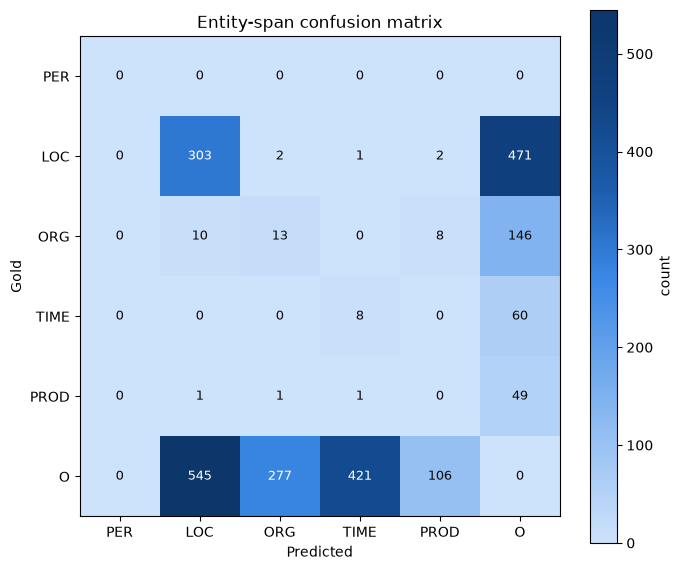

In [9]:
# Sequential blue ramp (light -> dark), from the project's validated reference palette.
BLUE_SEQUENTIAL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab", "#104281", "#0d366b"]
blue_cmap = LinearSegmentedColormap.from_list("blue_sequential", BLUE_SEQUENTIAL)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap=blue_cmap)
ax.set_xticks(range(len(ALL_LABELS)))
ax.set_yticks(range(len(ALL_LABELS)))
ax.set_xticklabels(ALL_LABELS)
ax.set_yticklabels(ALL_LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Gold")
ax.set_title("Entity-span confusion matrix")

vmax = cm.max() if cm.max() > 0 else 1
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > vmax * 0.5 else "#0b0b0b"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, label="count")
fig.tight_layout()
plt.show()

## 5. Expected Calibration Error (ECE)

Computed over predicted entities that have a confidence score, using `is_correct` (strict TP) as the binary outcome.

In [10]:
scored = pred_result.dropna(subset=["confidence"]).copy()
n_unscored = len(pred_result) - len(scored)
if n_unscored:
    print(f"{n_unscored} predictions have no confidence score and are excluded from ECE/AUPRC")


def expected_calibration_error(confidences: np.ndarray, correct: np.ndarray, n_bins: int = 10):
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    n = len(confidences)
    ece = 0.0
    bin_stats = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi) if i > 0 else (confidences >= lo) & (confidences <= hi)
        count = int(in_bin.sum())
        if count == 0:
            bin_stats.append({"bin_lo": lo, "bin_hi": hi, "count": 0, "avg_confidence": np.nan, "accuracy": np.nan})
            continue
        avg_conf = confidences[in_bin].mean()
        acc = correct[in_bin].mean()
        ece += (count / n) * abs(avg_conf - acc)
        bin_stats.append({"bin_lo": lo, "bin_hi": hi, "count": count, "avg_confidence": avg_conf, "accuracy": acc})
    return ece, pd.DataFrame(bin_stats)


ece, bin_stats_df = expected_calibration_error(scored["confidence"].to_numpy(), scored["is_correct"].to_numpy())
print(f"ECE = {ece:.4f}")
bin_stats_df

ECE = 0.5803


,bin_lo,bin_hi,count,avg_confidence,accuracy
0,0.0,0.1,0,NaN,NaN
1,0.1,0.2,0,NaN,NaN
2,0.2,0.3,0,NaN,NaN
3,0.3,0.4,0,NaN,NaN
4,0.4,0.5,0,NaN,NaN
5,0.5,0.6,340,0.548650,0.067647
6,0.6,0.7,302,0.648478,0.079470
7,0.7,0.8,268,0.749293,0.123134
8,0.8,0.9,362,0.853506,0.176796
9,0.9,1.0,463,0.947571,0.388769


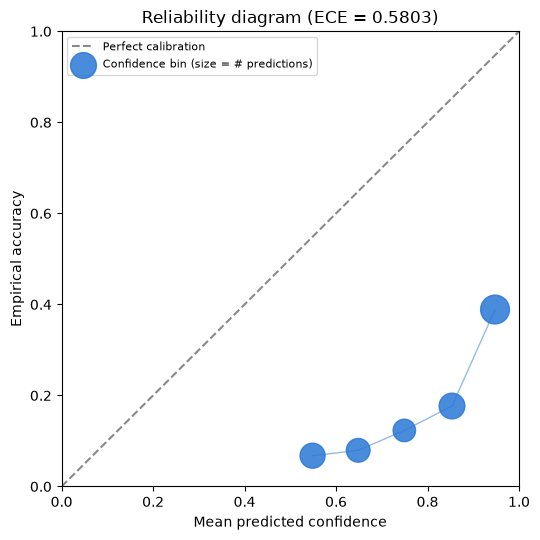

In [11]:
plot_bins = bin_stats_df.dropna(subset=["avg_confidence"])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], linestyle="--", color="#8a8a86", label="Perfect calibration")
ax.scatter(
    plot_bins["avg_confidence"],
    plot_bins["accuracy"],
    s=plot_bins["count"] / plot_bins["count"].max() * 400 + 30,
    color="#2a78d6",
    alpha=0.85,
    label="Confidence bin (size = # predictions)",
)
ax.plot(plot_bins["avg_confidence"], plot_bins["accuracy"], color="#2a78d6", linewidth=1, alpha=0.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Empirical accuracy")
ax.set_title(f"Reliability diagram (ECE = {ece:.4f})")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## 6. AUPRC (Area Under the Precision-Recall Curve)

Ranks predictions by confidence and treats `is_correct` as the positive class.

AUPRC = 0.4295  (baseline / random = prevalence = 0.1867)


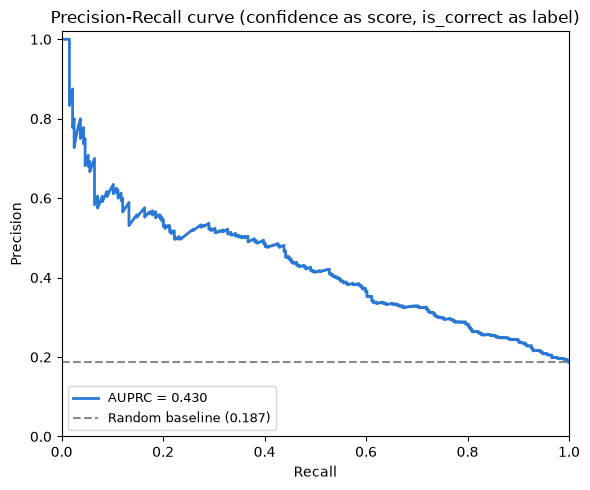

In [12]:
y_scores = scored["confidence"].to_numpy()
y_is_correct = scored["is_correct"].to_numpy().astype(int)

auprc = average_precision_score(y_is_correct, y_scores)
prevalence = y_is_correct.mean()
print(f"AUPRC = {auprc:.4f}  (baseline / random = prevalence = {prevalence:.4f})")

pr_precision, pr_recall, _ = precision_recall_curve(y_is_correct, y_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(pr_recall, pr_precision, color="#2a78d6", linewidth=2, label=f"AUPRC = {auprc:.3f}")
ax.axhline(prevalence, linestyle="--", color="#8a8a86", label=f"Random baseline ({prevalence:.3f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve (confidence as score, is_correct as label)")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

## 7. Summary

In [13]:
summary = {
    "predictions_file": PRED_PATH,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "micro_precision": micro_p,
    "micro_recall": micro_r,
    "micro_f1": micro_f1,
    "ECE": ece,
    "AUPRC": auprc,
    "n_scored_for_ece_auprc": len(scored),
    "n_excluded_no_confidence": n_unscored,
}
pd.Series(summary)

predictions_file            hipe2020_dev_fr_gliner_ner.csv
TP                                                     324
FP                                                    1411
FN                                                    1405
micro_precision                                   0.186744
micro_recall                                      0.187392
micro_f1                                          0.187067
ECE                                               0.580338
AUPRC                                             0.429544
n_scored_for_ece_auprc                                1735
n_excluded_no_confidence                                 0
dtype: object

## 8. Stratified by gold OCR token quality

Splits the evaluation above into two groups by looking up, for every predicted/missed entity span, whether any of its underlying gold tokens had `ocr_word_known == False` (an OCR error) in `hipe2020_dev_fr_ocrqa.csv`:

- **OCR correct**: no unrecognized word overlaps the span.
- **OCR error in span**: at least one token overlapping the span was flagged unknown by the OCR-QA bloom filter.

This directly targets the project's core research question -- does OCR quality relate to NER/NEL correctness? -- by comparing precision/recall/F1 and the confusion matrix between the two groups. Punctuation-only tokens (`ocr_word_known == None`) never count as an error, consistent with the convention used throughout the extraction notebook.

In [14]:
def build_token_offsets(df: pd.DataFrame) -> pd.DataFrame:
    """Per-token character offsets within its reconstructed sentence, plus ocr_word_known,
    for looking up OCR quality under any character span (gold or predicted). Mirrors the
    same detokenization rules as build_gold."""
    rows = []
    doc_id = None
    sent_idx = 0
    cur_len = 0
    no_space_before_next = False
    first_in_sentence = True

    for _, row in df.iterrows():
        if row["document_id"] != doc_id:
            doc_id = row["document_id"]
            sent_idx = 0
            cur_len = 0
            no_space_before_next = False
            first_in_sentence = True

        misc = str(row["MISC"])
        token = str(row["token"])

        if not first_in_sentence and not no_space_before_next:
            cur_len += 1
        start = cur_len
        cur_len += len(token)
        end = cur_len
        first_in_sentence = False
        no_space_before_next = "NoSpaceAfter" in misc

        rows.append(
            {
                "document_id": doc_id,
                "sentence_id": sent_idx,
                "start": start,
                "end": end,
                "ocr_word_known": row["ocr_word_known"],
            }
        )

        if "EndOfSentence" in misc:
            sent_idx += 1
            cur_len = 0
            no_space_before_next = False
            first_in_sentence = True

    return pd.DataFrame(rows)


def is_ocr_unknown(value) -> bool:
    """True only for an explicit OCR-unknown token; NaN/None (punctuation, not applicable)
    and True (known word) both return False."""
    if pd.isna(value):
        return False
    return str(value).strip().lower() == "false"


token_offsets_df = build_token_offsets(gold_tokens_df)

token_offsets_by_sentence: dict[tuple, list[tuple]] = {
    key: list(zip(g["start"], g["end"], g["ocr_word_known"]))
    for key, g in token_offsets_df.groupby(["document_id", "sentence_id"])
}


def span_has_ocr_error(document_id, sentence_id, start, end) -> bool:
    for t_start, t_end, ocr_known in token_offsets_by_sentence.get((document_id, sentence_id), []):
        if t_end > start and t_start < end and is_ocr_unknown(ocr_known):
            return True
    return False

In [15]:
def classify_span(row) -> str:
    has_error = span_has_ocr_error(row["document_id"], row["sentence_id"], row["start"], row["end"])
    return "OCR error in span" if has_error else "OCR correct"


pred_result["ocr_group"] = pred_result.apply(classify_span, axis=1)
fn_df["ocr_group"] = fn_df.apply(classify_span, axis=1)

pd.concat([pred_result["ocr_group"], fn_df["ocr_group"]]).value_counts()

ocr_group
OCR correct          2878
OCR error in span     262
Name: count, dtype: int64

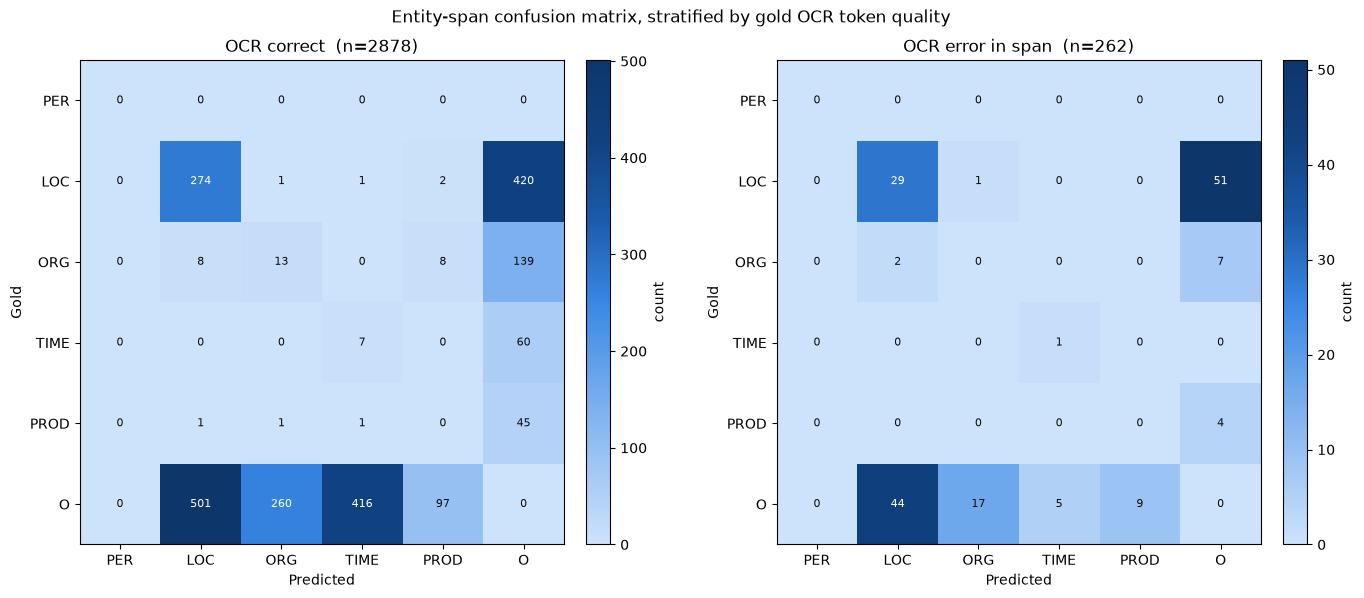

,TP,FP,FN,precision,recall,f1
OCR correct,294.0,1330.0,1254.0,0.181034,0.189922,0.185372
OCR error in span,30.0,81.0,151.0,0.270270,0.165746,0.205479


In [16]:
OCR_GROUPS = ["OCR correct", "OCR error in span"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
group_stats = {}

for ax, group in zip(axes, OCR_GROUPS):
    pred_g = pred_result[pred_result["ocr_group"] == group]
    fn_g = fn_df[fn_df["ocr_group"] == group]

    y_true_g = list(pred_g["true_label"]) + list(fn_g["label"])
    y_pred_g = list(pred_g["entity_label"]) + ["O"] * len(fn_g)
    cm_g = confusion_matrix(y_true_g, y_pred_g, labels=ALL_LABELS)
    vmax_g = cm_g.max() if cm_g.max() > 0 else 1

    im = ax.imshow(cm_g, cmap=blue_cmap, vmin=0, vmax=vmax_g)
    ax.set_xticks(range(len(ALL_LABELS)))
    ax.set_yticks(range(len(ALL_LABELS)))
    ax.set_xticklabels(ALL_LABELS)
    ax.set_yticklabels(ALL_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")
    ax.set_title(f"{group}  (n={len(pred_g) + len(fn_g)})")

    for i in range(cm_g.shape[0]):
        for j in range(cm_g.shape[1]):
            color = "white" if cm_g[i, j] > vmax_g * 0.5 else "#0b0b0b"
            ax.text(j, i, str(cm_g[i, j]), ha="center", va="center", color=color, fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="count")

    tp_g = int(pred_g["is_correct"].sum())
    fp_g = int((~pred_g["is_correct"]).sum())
    fn_g_count = len(fn_g)
    p_g = tp_g / (tp_g + fp_g) if (tp_g + fp_g) else 0.0
    r_g = tp_g / (tp_g + fn_g_count) if (tp_g + fn_g_count) else 0.0
    f1_g = 2 * p_g * r_g / (p_g + r_g) if (p_g + r_g) else 0.0
    group_stats[group] = {"TP": tp_g, "FP": fp_g, "FN": fn_g_count, "precision": p_g, "recall": r_g, "f1": f1_g}

fig.suptitle("Entity-span confusion matrix, stratified by gold OCR token quality")
fig.tight_layout()
plt.show()

pd.DataFrame(group_stats).T